
Operation: generate_report


/var/folders/xh/kj8mjqr14z70q579rsg11v2r0000gn/T/ipykernel_13687/1879241794.py:140: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y], labels=[v_unopt, v_opt], widths=0.6)


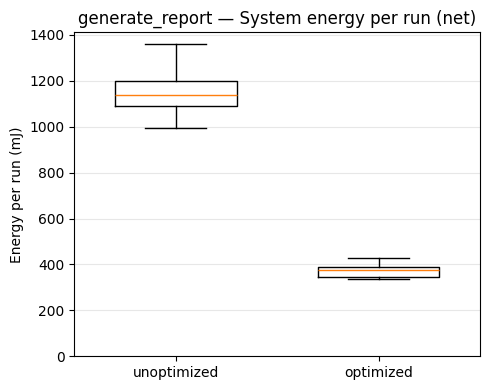

System energy per run (net)
unoptimized: 1145.136 mJ (95% CI [1098.800, 1191.472])
optimized:   374.613 mJ (95% CI [360.401, 388.824])
Welch t-test p = 3.60e-19
Mann–Whitney U p = 3.23e-07
Cohen's d = 11.505
Cliff's delta = 1.000 (large)


Operation: get_item_price


/var/folders/xh/kj8mjqr14z70q579rsg11v2r0000gn/T/ipykernel_13687/1879241794.py:140: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y], labels=[v_unopt, v_opt], widths=0.6)


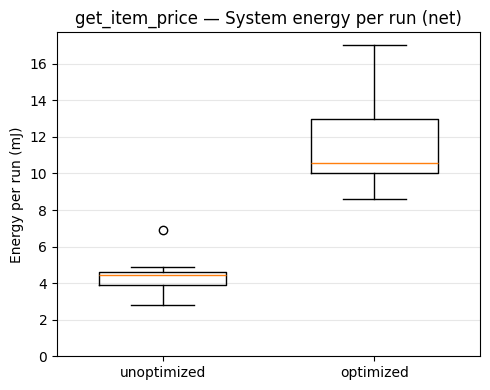

System energy per run (net)
unoptimized: 4.328 mJ (95% CI [3.892, 4.764])
optimized:   11.424 mJ (95% CI [10.359, 12.490])
Welch t-test p = 5.85e-12
Mann–Whitney U p = 3.23e-07
Cohen's d = -4.462
Cliff's delta = -1.000 (large)


Operation: timeline


/var/folders/xh/kj8mjqr14z70q579rsg11v2r0000gn/T/ipykernel_13687/1879241794.py:140: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y], labels=[v_unopt, v_opt], widths=0.6)


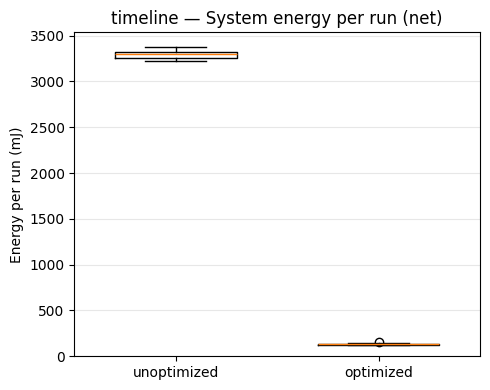

System energy per run (net)
unoptimized: 3293.567 mJ (95% CI [3271.285, 3315.849])
optimized:   134.255 mJ (95% CI [129.119, 139.391])
Welch t-test p = 7.91e-36
Mann–Whitney U p = 3.23e-07
Cohen's d = 99.984
Cliff's delta = 1.000 (large)



In [ ]:
# statistical analysis used in the paper (total energy metric only, system and process level measurments, only the experiments reportet in the paper)
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import ScalarFormatter

DATA_DIR = Path("../data/experiment_results_raw")


ALLOWED_EXPERIMENTS = {
    "timeline",
    "generate_report",
    "get_item_price",
}


METRICS = {
    "System energy per run (net)": "net_sys_host_per_run_J",
}


def mean_ci(x, alpha=0.05):
    x = np.asarray(x)
    m = x.mean()
    h = stats.sem(x) * stats.t.ppf(1 - alpha/2, len(x)-1)
    return m, m - h, m + h

def cliffs_delta(x, y):
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    delta = (gt - lt) / (len(x) * len(y))
    mag = (
        "negligible" if abs(delta) < 0.147 else
        "small" if abs(delta) < 0.33 else
        "medium" if abs(delta) < 0.474 else
        "large"
    )
    return delta, mag

def remove_outliers(x, lower_q=0.005, upper_q=0.995):
    lo, hi = np.quantile(x, [lower_q, upper_q])
    return x[(x >= lo) & (x <= hi)]

def format_p(p, threshold=1e-6):
    if p < threshold:
        return f"{p:.2e}"
    else:
        return f"{p:.6f}"

experiments = {}

for f in DATA_DIR.glob("energy_results_*.json"):
    stem = f.stem.replace("energy_results_", "")
    op, suffix = stem.rsplit("_", 1)
    experiments.setdefault(op, {})[suffix] = f


for operation, files in experiments.items():

    if operation not in ALLOWED_EXPERIMENTS:
        continue

    if len(files) != 2:
        continue

    print("\n" + "="*60)
    print(f"Operation: {operation}")
    print("="*60)

    # Load data
    frames = []

    for suffix, path in files.items():
        with open(path) as f:
            trials = json.load(f)["trials"]

        df = pd.DataFrame(trials)
        df["variant"] = suffix
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)

    # Convert J → mJ
    for c in df.columns:
        if c.endswith("_J"):
            df[c.replace("_J", "_mJ")] = df[c] * 1000

    variants = df["variant"].unique().tolist()

    v_unopt = next(v for v in variants if "unoptimized" in v.lower())
    v_opt   = next(v for v in variants if "optimized" in v.lower() and "unoptimized" not in v.lower())



    for label, base_col in METRICS.items():

        col = base_col.replace("_J", "_mJ")

        x = df[df["variant"] == v_unopt][col].dropna().to_numpy()
        y = df[df["variant"] == v_opt][col].dropna().to_numpy()

        # Remove outliers
        x = remove_outliers(x)
        y = remove_outliers(y)


        fig, ax = plt.subplots(figsize=(5,4))

        ax.boxplot([x, y], labels=[v_unopt, v_opt], widths=0.6)

        ax.set_title(f"{operation} — {label}")
        ax.set_ylabel("Energy per run (mJ)")
        ax.set_ylim(bottom=0)

        ax.grid(axis="y", alpha=0.3)

        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
        ax.ticklabel_format(style="plain", axis="y")

        plt.tight_layout()
        plt.show()


        m1, l1, h1 = mean_ci(x)
        m2, l2, h2 = mean_ci(y)

        t, p_t = stats.ttest_ind(x, y, equal_var=False)
        u, p_u = stats.mannwhitneyu(x, y, alternative="two-sided")

        pooled = np.sqrt((x.var() + y.var()) / 2)
        d = (m1 - m2) / pooled if pooled > 0 else 0.0

        delta, mag = cliffs_delta(x, y)

        print(label)
        print(f"{v_unopt}: {m1:.3f} mJ (95% CI [{l1:.3f}, {h1:.3f}])")
        print(f"{v_opt}:   {m2:.3f} mJ (95% CI [{l2:.3f}, {h2:.3f}])")

        print(f"Welch t-test p = {format_p(p_t)}")
        print(f"Mann–Whitney U p = {format_p(p_u)}")
        print(f"Cohen's d = {d:.3f}")
        print(f"Cliff's delta = {delta:.3f} ({mag})")
        print()